# 3d. Calculate <i>f</i><sub>O<sub>2</sub></sub> including uncertainties

This time, we'll include measurement uncertainties in the calculations. 

## Python set-up
You need to install VolFe once on your machine, if you haven't yet. Then we need to import a few Python packages (including VolFe). 

In [1]:
# Install VolFe on your machine. Don't remove the # from this line!
# pip install VolFe # Remove the first # in this line if you have not installed VolFe on your machine before.

# import python packages
import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf

## Import data

We'll use the examples_marianas_wT csv in files and use all the default options again. 

The data in this file are from Brounce et al. (2014) and Kelley & Cottrell (2012) with updated values for Fe<sup>3+</sup>/Fe<sub>T</sub> from Cottrell et al. (2021) where available.

In [2]:
# Read csv to define melt composition
my_analyses = pd.read_csv("../files/example_marianas_wT.csv") 

## Run the calculation

Here we'll use a Monte Carlo approach using the uncertainties on the inputs to calculate the undertainties on the calculation outputs. To include the uncertainties there needs to be a column with one standard deviation included (e.g., SiO2_sd). The uncertainties are either given as relative (R, fraction) or absolute (A - i.e., same units as the parameter), indicated with a sd_type column (e.g., SiO2_sd_type) - if no type is given, its assumed to be absolute. If no column is present, it is assumed the uncertainty is 0. The number of iterations is how many random compositions within error are used for each calculation.

In [3]:
# runs the calculation
results = vf.calc_comp_error_function(my_analyses,iterations=100,function='calc_melt_S_oxybarometer')

100%|██████████| 51/51 [3:32:03<00:00, 249.48s/it]    


And we can plot these against the volatile content.
This shows that the pressure is mostly controlled by CO<sub>2</sub> and H<sub>2</sub>O content, which are correlated.

(4500.0, 0.0)

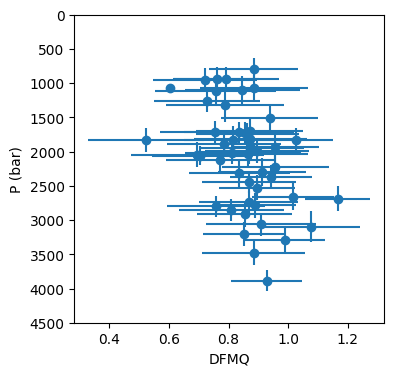

In [4]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

# Plotting data

data = results[results['fO2_DFMQ_sulf'] != ""] # all calculations

ax1.errorbar(data['fO2_DFMQ_sulf'], data['P_bar_sulf'], xerr=data['fO2_DFMQ_sulf_sd'], yerr=data['P_bar_sulf_sd'], fmt='o')

ax1.set_xlabel('DFMQ')
ax1.set_ylabel('P (bar)')
ax1.set_ylim([4500, 0])